# AWG5208 sequence-list Gaussian-square length sweep

This notebook demonstrates a hardware sequence list with six readout steps:
Gaussian-square pulse lengths from 100 ns through 600 ns.

- AWG CH3: 50 MHz Gaussian-square readout.
- AWG CH1 marker 1: ATS9371 trigger at the start of every readout.
- ATS9371: one 1 us record per sequence step.
- Playback order: 100, 200, ..., 600 ns, repeated for every average.
- Averaging: records are reshaped to `(average, sequence_step, time)` and
  matching traces are averaged along the first axis.

The sequence assets are uploaded once. The sweep does not re-upload a waveform
between points.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from awg_alazar import AWGAlazar
from awg5200 import gaussian_square_ns, marker_window_ns

## Experiment parameters

In [21]:
AWG_RESOURCE = "TCPIP0::192.168.10.171::inst0::INSTR"

AWG_SAMPLE_RATE_HZ = 2.5e9
ALAZAR_SAMPLE_RATE_HZ = 1e9
CARRIER_FREQUENCY_HZ = 50e6
ADC_CHANNEL = "CHB"

READOUT_CHANNEL = 3
MARKER_CHANNEL = 1
MARKER_NUMBER = 1
CHANNEL_AMPLITUDE_VPP = 0.5
MARKER_LOW_VOLTS = 0.0
MARKER_HIGH_VOLTS = 1.2

PULSE_LENGTHS_NS = np.arange(100, 601, 100)
PULSE_START_NS = 100
EDGE_SIGMA_NS = 10
PULSE_PEAK_VOLTS = 0.02

# A fixed step length keeps the trigger cadence independent of pulse length.
SEQUENCE_STEP_NS = 1500
MARKER_WIDTH_NS = 40

ACQUIRE_WINDOW_NS = 1000
NUM_AVERAGES = 500
MOVING_AVERAGE_TIME_NS = 20
ALAZAR_TIMEOUT_MS = 60_000

## Connect and configure AWG5208 + ATS9371

In [22]:
experiment = AWGAlazar.connect(
    AWG_RESOURCE,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    tone_frequency_hz=CARRIER_FREQUENCY_HZ,
    trigger_delay_s=0.0,
    acquire_window_ns=ACQUIRE_WINDOW_NS,
    integrate_window_ns=(0, ACQUIRE_WINDOW_NS),
    adc_channel=ADC_CHANNEL,
    moving_average_time_s=MOVING_AVERAGE_TIME_NS * 1e-9,
    timeout_ms=ALAZAR_TIMEOUT_MS,
    use_external_10mhz_reference=True,
)

print("AWG:", experiment.awg.identify())
print("Pulse lengths (ns):", PULSE_LENGTHS_NS.tolist())
print("ATS record:", experiment.acquire_window_cycles, "samples")
print("Total ATS records:", NUM_AVERAGES * len(PULSE_LENGTHS_NS))

AWG: TEKTRONIX,AWG5208,B030598,FV:6.6.0131.0
Pulse lengths (ns): [100, 200, 300, 400, 500, 600]
ATS record: 1024 samples
Total ATS records: 3000


## Build waveform assets

Every sequence step has the same total duration. CH3 contains the modulated
readout, while CH1 is a zero-valued analog waveform carrying marker 1. The
marker rising edge occurs at `PULSE_START_NS`.

In [23]:
experiment.awg.clear_all()

step_samples = experiment.ns2cycles(SEQUENCE_STEP_NS, inst="dac")
pulse_start_sample = experiment.ns2cycles(PULSE_START_NS, inst="dac")
step_time_s = np.arange(step_samples) / AWG_SAMPLE_RATE_HZ

readout_assets = []
marker_assets = []

for pulse_length_ns in PULSE_LENGTHS_NS:
    envelope = gaussian_square_ns(
        duration_ns=float(pulse_length_ns),
        sample_rate_hz=AWG_SAMPLE_RATE_HZ,
        edge_sigma_ns=EDGE_SIGMA_NS,
        amplitude_volts=PULSE_PEAK_VOLTS,
    )
    full_envelope = np.zeros(step_samples)
    pulse_stop_sample = pulse_start_sample + envelope.size
    full_envelope[pulse_start_sample:pulse_stop_sample] = envelope

    readout_values = full_envelope * np.sin(
        2 * np.pi * CARRIER_FREQUENCY_HZ * step_time_s
    )
    marker_values = marker_window_ns(
        duration_ns=SEQUENCE_STEP_NS,
        sample_rate_hz=AWG_SAMPLE_RATE_HZ,
        start_ns=PULSE_START_NS,
        stop_ns=PULSE_START_NS + MARKER_WIDTH_NS,
    )

    suffix = f"{int(pulse_length_ns)}ns"
    readout_assets.append(
        experiment.awg.upload_waveform_asset(
            name=f"seq_readout_{suffix}",
            waveform_volts=readout_values,
            amplitude_vpp=CHANNEL_AMPLITUDE_VPP,
        )
    )
    marker_assets.append(
        experiment.awg.upload_waveform_asset(
            name=f"seq_marker_{suffix}",
            waveform_volts=np.zeros(step_samples),
            amplitude_vpp=CHANNEL_AMPLITUDE_VPP,
            markers=(marker_values,),
        )
    )

print("Readout assets:", readout_assets)
print("Marker assets:", marker_assets)

Readout assets: ['seq_readout_100ns', 'seq_readout_200ns', 'seq_readout_300ns', 'seq_readout_400ns', 'seq_readout_500ns', 'seq_readout_600ns']
Marker assets: ['seq_marker_100ns', 'seq_marker_200ns', 'seq_marker_300ns', 'seq_marker_400ns', 'seq_marker_500ns', 'seq_marker_600ns']


## Create and assign the sequence list

In [24]:
experiment.awg.set_channel_amplitude(
    READOUT_CHANNEL,
    CHANNEL_AMPLITUDE_VPP,
)
experiment.awg.set_channel_resolution(READOUT_CHANNEL, 16)

experiment.awg.set_channel_amplitude(
    MARKER_CHANNEL,
    CHANNEL_AMPLITUDE_VPP,
)
experiment.awg.set_channel_resolution(
    MARKER_CHANNEL,
    16 - MARKER_NUMBER,
)
experiment.awg.set_marker_levels(
    MARKER_CHANNEL,
    MARKER_NUMBER,
    MARKER_LOW_VOLTS,
    MARKER_HIGH_VOLTS,
)

sequence_name = experiment.awg.create_sequence(
    "gaussian_square_length_sweep",
    tracks={
        MARKER_CHANNEL: marker_assets,
        READOUT_CHANNEL: readout_assets,
    },
    repetitions=1,
    goto_step=1,
)

print("Sequence:", sequence_name)
print("Steps:", len(PULSE_LENGTHS_NS))
print("Playback: 100 -> 200 -> ... -> 600 ns -> step 1")
print("AWG error:", experiment.awg.error())

Sequence: gaussian_square_length_sweep
Steps: 6
Playback: 100 -> 200 -> ... -> 600 ns -> step 1
AWG error: 0,"No error"


## Acquire all interleaved records

The AWG sequence loops continuously after it starts. ATS receives:

```text
average 0: step 0, step 1, ..., step 5
average 1: step 0, step 1, ..., step 5
...
```

`acquire_sequence_traces()` reshapes that flat stream and returns one averaged
raw trace and one averaged IQ trace for every pulse length.

In [25]:
(
    raw_time_s,
    average_raw_traces,
    iq_time_s,
    average_iq_traces,
) = experiment.acquire_sequence_traces(
    number_of_steps=len(PULSE_LENGTHS_NS),
    number_of_averages=NUM_AVERAGES,
)

sequence_records = experiment.last_sequence_records_volts
sequence_shot_iq = experiment.last_sequence_shot_iq

print("Raw sequence records:", sequence_records.shape)
print("Raw averaged traces:", average_raw_traces.shape)
print("IQ sequence records:", sequence_shot_iq.shape)
print("IQ averaged traces:", average_iq_traces.shape)
print("AWG error:", experiment.awg.error())

Raw sequence records: (500, 6, 1024)
Raw averaged traces: (6, 1024)
IQ sequence records: (500, 6, 1005)
IQ averaged traces: (6, 1005)
AWG error: 0,"No error"


## Explicit trace-by-trace averaging

This cell shows the averaging operation directly. For each sequence step, it
selects the same trace from every sequence cycle and averages only those
matching records.

In [26]:
trace_by_trace_average = np.empty_like(average_raw_traces)

for step_index, pulse_length_ns in enumerate(PULSE_LENGTHS_NS):
    matching_traces = sequence_records[:, step_index, :]
    trace_by_trace_average[step_index] = np.mean(
        matching_traces,
        axis=0,
    )
    print(
        f"{pulse_length_ns:3d} ns: "
        f"{matching_traces.shape[0]} traces averaged"
    )

np.testing.assert_allclose(
    trace_by_trace_average,
    average_raw_traces,
)
print("Trace-by-trace average matches acquire_sequence_traces().")

100 ns: 500 traces averaged
200 ns: 500 traces averaged
300 ns: 500 traces averaged
400 ns: 500 traces averaged
500 ns: 500 traces averaged
600 ns: 500 traces averaged
Trace-by-trace average matches acquire_sequence_traces().


## Plot averaged raw ADC traces

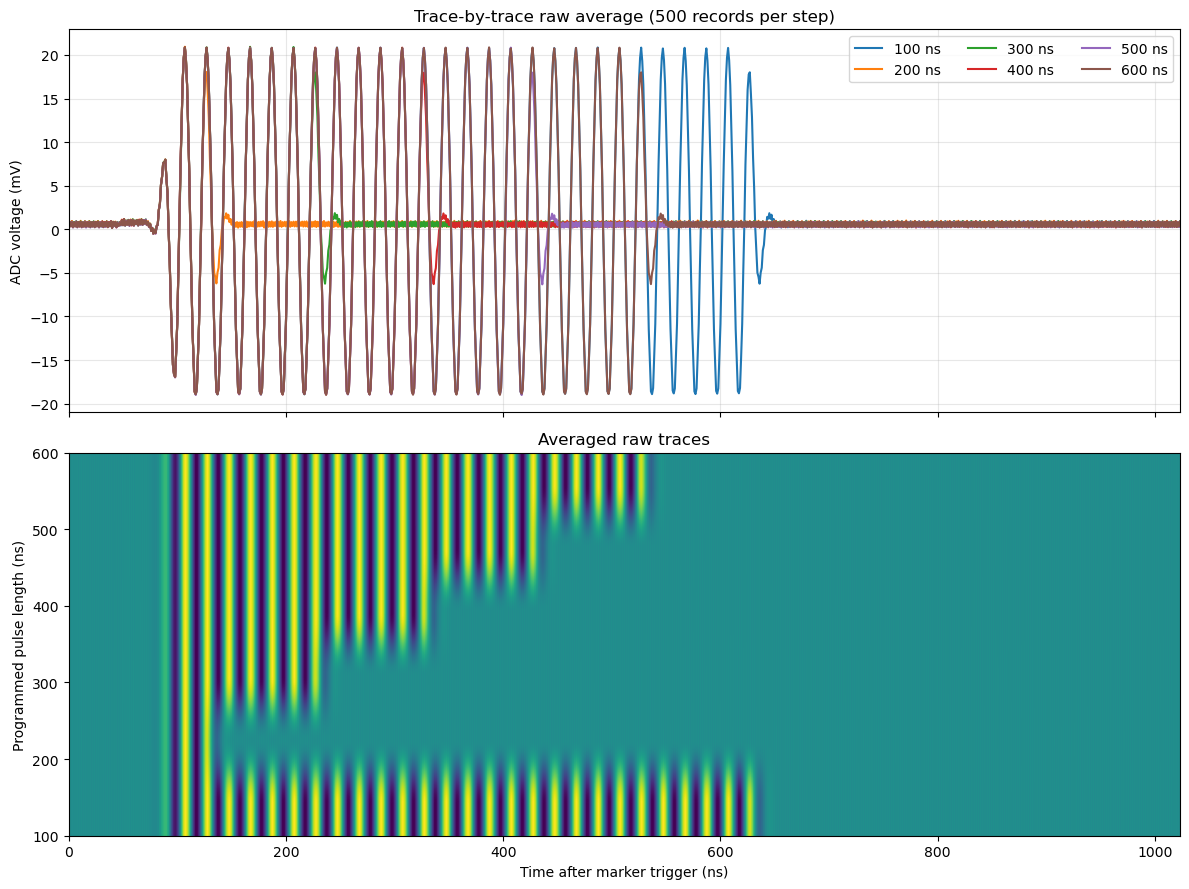

In [27]:
raw_time_ns = raw_time_s * 1e9

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
for step_index, pulse_length_ns in enumerate(PULSE_LENGTHS_NS):
    axes[0].plot(
        raw_time_ns,
        average_raw_traces[step_index] * 1e3,
        label=f"{pulse_length_ns} ns",
    )
axes[0].set_ylabel("ADC voltage (mV)")
axes[0].set_title(
    f"Trace-by-trace raw average ({NUM_AVERAGES} records per step)"
)
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=3)

axes[1].imshow(
    average_raw_traces * 1e3,
    aspect="auto",
    origin="lower",
    extent=[
        raw_time_ns[0],
        raw_time_ns[-1],
        PULSE_LENGTHS_NS[0],
        PULSE_LENGTHS_NS[-1],
    ],
)
axes[1].set_xlabel("Time after marker trigger (ns)")
axes[1].set_ylabel("Programmed pulse length (ns)")
axes[1].set_title("Averaged raw traces")

plt.tight_layout()
plt.show()

## Plot moving-averaged IQ envelopes

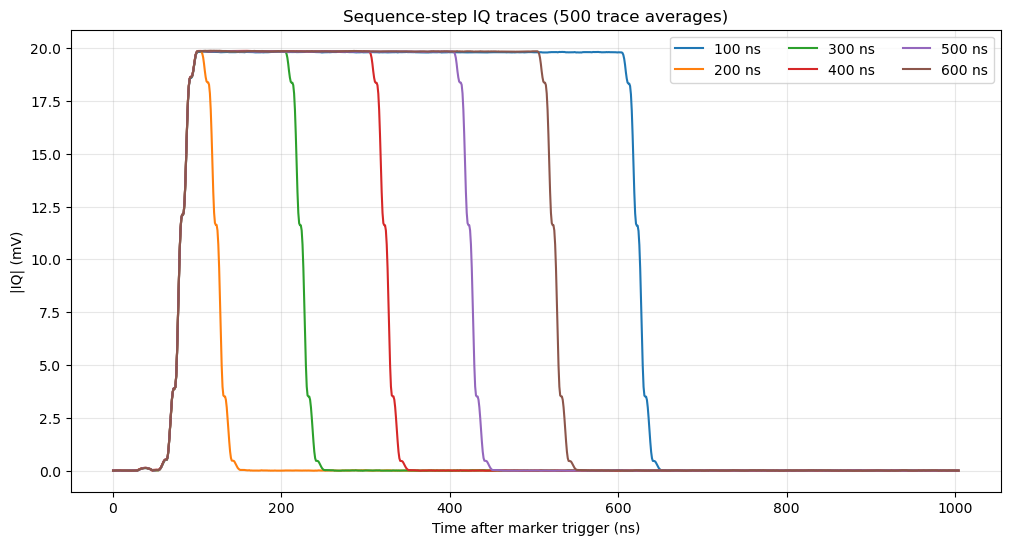

In [28]:
iq_time_ns = iq_time_s * 1e9

plt.figure(figsize=(12, 6))
for step_index, pulse_length_ns in enumerate(PULSE_LENGTHS_NS):
    plt.plot(
        iq_time_ns,
        np.abs(average_iq_traces[step_index]) * 1e3,
        label=f"{pulse_length_ns} ns",
    )
plt.xlabel("Time after marker trigger (ns)")
plt.ylabel("|IQ| (mV)")
plt.title(
    f"Sequence-step IQ traces ({NUM_AVERAGES} trace averages)"
)
plt.grid(True, alpha=0.3)
plt.legend(ncol=3)
plt.show()

## Save the sequence acquisition

In [29]:
np.savez(
    "sequence_length_sweep_capture.npz",
    pulse_lengths_ns=PULSE_LENGTHS_NS,
    raw_time_s=raw_time_s,
    sequence_records_volts=sequence_records,
    average_raw_traces=average_raw_traces,
    iq_time_s=iq_time_s,
    sequence_shot_iq=sequence_shot_iq,
    average_iq_traces=average_iq_traces,
)
print("Saved sequence_length_sweep_capture.npz")

Saved sequence_length_sweep_capture.npz


## Close hardware sessions

In [30]:
experiment.close()
print("AWG VISA session closed")

AWG VISA session closed
